In [2]:
import pandas as pd
import ast
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# In round 1 of hyperparameter tuning we considered batch_size, learning rate, optimizer, and width. In round 2 
# we considered depth, dropout and threshold. 

with open('../data/hyperparameters/best_hyperparameters.txt', 'r') as file:
    lines = file.readlines()

data = []
for line in lines[1:]:
    line = line.strip().split('\t')
    try:
        hyperparams = ast.literal_eval(line[2])  # Use ast.literal_eval
    except (SyntaxError, ValueError):
        print(f"Error evaluating literal on line: {line}")
        continue

    data.append([float(line[1])] + list(hyperparams.values()))

columns = ['Metric Value'] + list(hyperparams.keys())
df = pd.DataFrame(data, columns=columns)
df = df.rename_axis('ID').reset_index()

df_sorted = df.sort_values(by='Metric Value', ascending=False)
df_sorted

,ID,Metric Value,depth,dropout,threshold
33,33,0.715632,2,0.3,0.35
49,49,0.714884,5,0.5,0.60
3,3,0.714361,5,0.0,0.60
34,34,0.713739,2,0.1,0.60
21,21,0.713205,6,0.0,0.70
26,26,0.711632,4,0.3,0.60
32,32,0.711323,6,0.1,0.20
30,30,0.711298,7,0.1,0.55
27,27,0.710850,7,0.5,0.80
31,31,0.710558,2,0.0,0.55


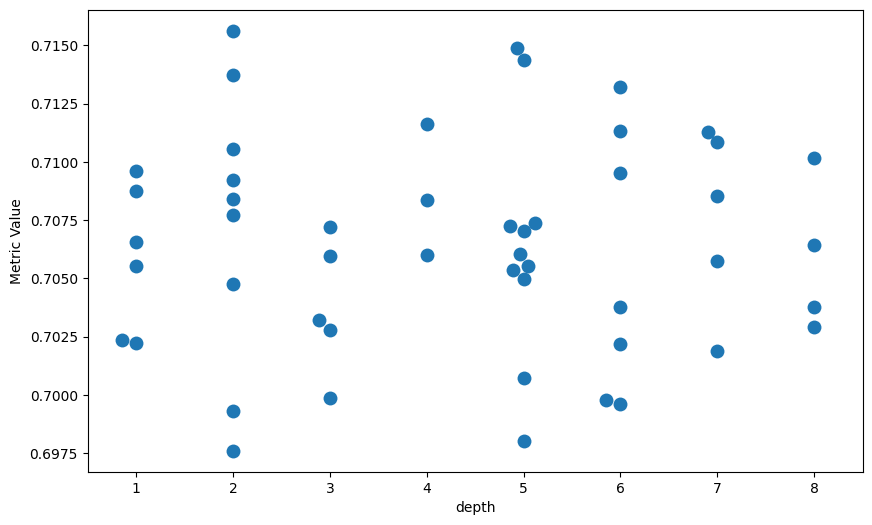

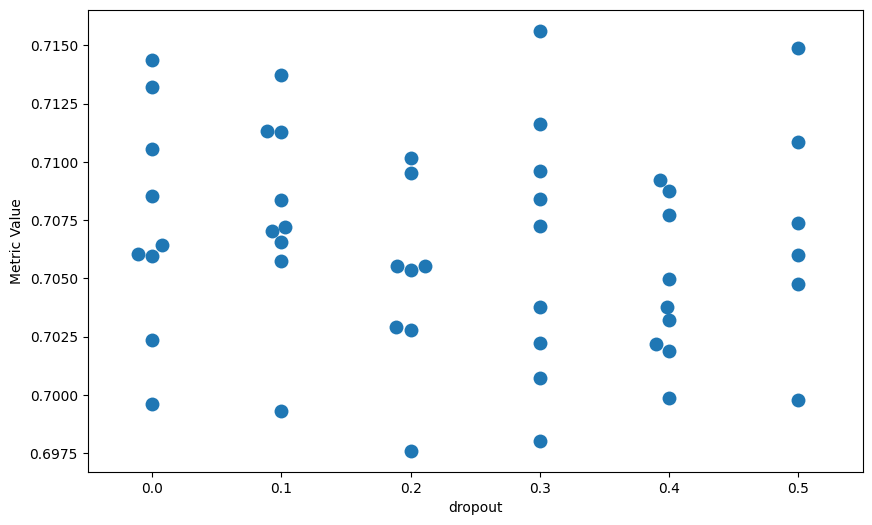

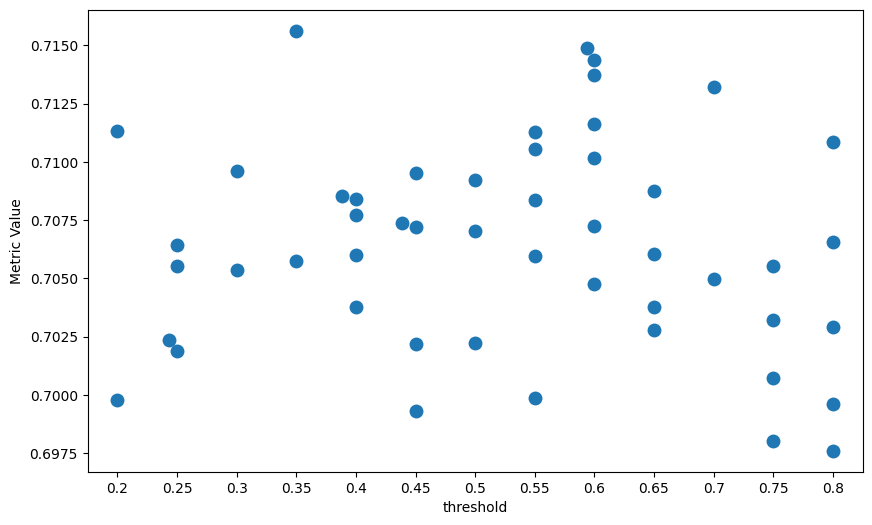

In [14]:
for hyperparam in list(hyperparams.keys()):
    rounded_values = df_sorted[hyperparam].round(2)  # Round to 2 decimal places
    df_rounded = pd.DataFrame({hyperparam: rounded_values, 'Metric Value': df_sorted['Metric Value']})
    plt.figure(figsize=(10, 6))
    sns.swarmplot(data=df_rounded, x=hyperparam, y='Metric Value', s=10)
    #plt.title(f'Swarm Plot of Metric Value vs {hyperparam}')
    plt.xlabel(hyperparam)
    plt.ylabel('Metric Value')
    plt.savefig(f"../plots/hyperparam_optimization/{hyperparam}_2.pdf", dpi=600) 
    plt.show()

In [3]:
    if hyperparam == 'lr' or hyperparam == 'width_1' or hyperparam == 'batch_size':
        plt.xscale('log') 